In [6]:
from ultralytics import YOLO, models
import pandas as pd

data =  "VisDrone"
data = "DOTA"


models = []
datas = []

if data == "DOTA":
    models = ["yolov12n-DOTA","yolov12n-ca2-DOTA","yolo12-gl-cab-ca2-DOTA"]
    datas = ["DOTAv1.5","DOTAv1.5-SMALL","DOTAv1.5-MEDIUM","DOTAv1.5-LARGE"]
elif data == "VisDrone":
    models = ["yolov12n-VisDrone","yolov12n-ca2-VisDrone","yolo12-gl-cab-ca2-VisDrone"]
    datas = ["VisDrones-SMALL","VisDrones-MEDIUM","VisDrones-LARGE"]

df_dota_object_stats = []
for _model in models:
    model = YOLO(f"resultats/{_model}-200.pt")

    for data in datas:
        results = model.val(data=f"/Users/osias/Documents/PHD/CODE/ultralytics-git/code/ultralytics/cfg/datasets/{data}.yaml", plots=True)
        line = {'DataSet':data,'Model':_model,
        'P':results.results_dict['metrics/precision(B)'], 'R':results.results_dict['metrics/recall(B)'], 'mAP50':results.results_dict['metrics/mAP50(B)'], 'mAP50-95':results.results_dict['metrics/mAP50-95(B)'], 'preprocess':results.speed['preprocess'], 'inference':results.speed['inference'],'postprocess':results.speed['postprocess'],'loss':results.speed['loss']}
        df_dota_object_stats.append(line)

df_dota_object_stats = pd.DataFrame(df_dota_object_stats)
df_dota_object_stats.to_csv(f"resultats/results_{data}.csv", index=False, sep=";")

Ultralytics 8.4.33 🚀 Python-3.9.18 torch-2.7.1 CPU (Apple M3 Pro)
YOLO12 summary (fused): 159 layers, 2,559,848 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 1520.0±760.2 MB/s, size: 688.1 KB)
val: Scanning /Users/osias/Documents/PHD/datasets/DOTAv1.5/labels/val.cache... 458 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 458/458 51.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.1s/it 1:302.2sss
                   all        458      69565      0.766      0.356      0.406      0.251
                 plane         71       2550      0.816      0.647       0.69      0.399
                  ship        138      10765      0.813      0.422       0.51      0.262
          storage tank         60       2940      0.806      0.191      0.287      0.134
      baseball diamond         53        213      0.912      0.389      0.485      0.264
          tennis court         

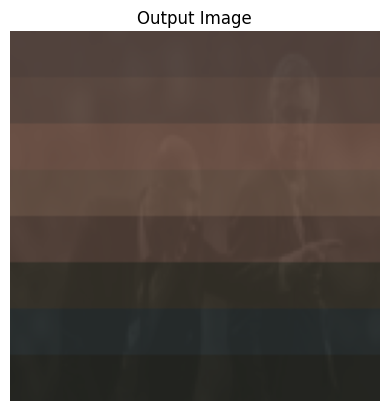

In [7]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# --- Self-attention simple (mock pour test) ---
def self_attention(x, heads=8):
    # x: (B, H, W, C)
    B, H, W, C = x.shape
    x = x.view(B, H * W, C)

    attn = torch.softmax(torch.matmul(x, x.transpose(-1, -2)) / (C ** 0.5), dim=-1)
    out = torch.matmul(attn, x)

    return out.view(B, H, W, C)

# --- Ton module ---
class CrossAreaAttention(nn.Module):
    def __init__(self, dim, l=4, heads=8):
        super().__init__()
        self.l = l
        self.heads = heads
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        B, H, W, C = x.shape

        assert H % self.l == 0 and W % self.l == 0

        xv = x.view(B * self.l, H // self.l, W, C)
        xv = self_attention(xv, self.heads)
        out_V = xv.view(B, H, W, C)

        xh = x.view(B * self.l, H, W // self.l, C)
        xh = self_attention(xh, self.heads)
        out_H = xh.view(B, H, W, C)

        alpha = torch.sigmoid(self.alpha)
        out = alpha * out_V + (1 - alpha) * out_H

        return out

# --- Charger une image ---
image = Image.open("/Users/osias/Documents/PHD/ultralytics-osias/ultralytics/assets/zidane.jpg").convert("RGB")

transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

img_tensor = transform(image)  # (C, H, W)
img_tensor = img_tensor.permute(1, 2, 0)  # (H, W, C)
img_tensor = img_tensor.unsqueeze(0)  # (1, H, W, C)

# --- Appliquer module ---
model = CrossAreaAttention(dim=3,l=8)
output = model(img_tensor)

# --- Affichage ---
out_img = output.squeeze(0).permute(2, 0, 1).detach()

plt.imshow(out_img.permute(1, 2, 0))
plt.title("Output Image")
plt.axis("off")
plt.show()

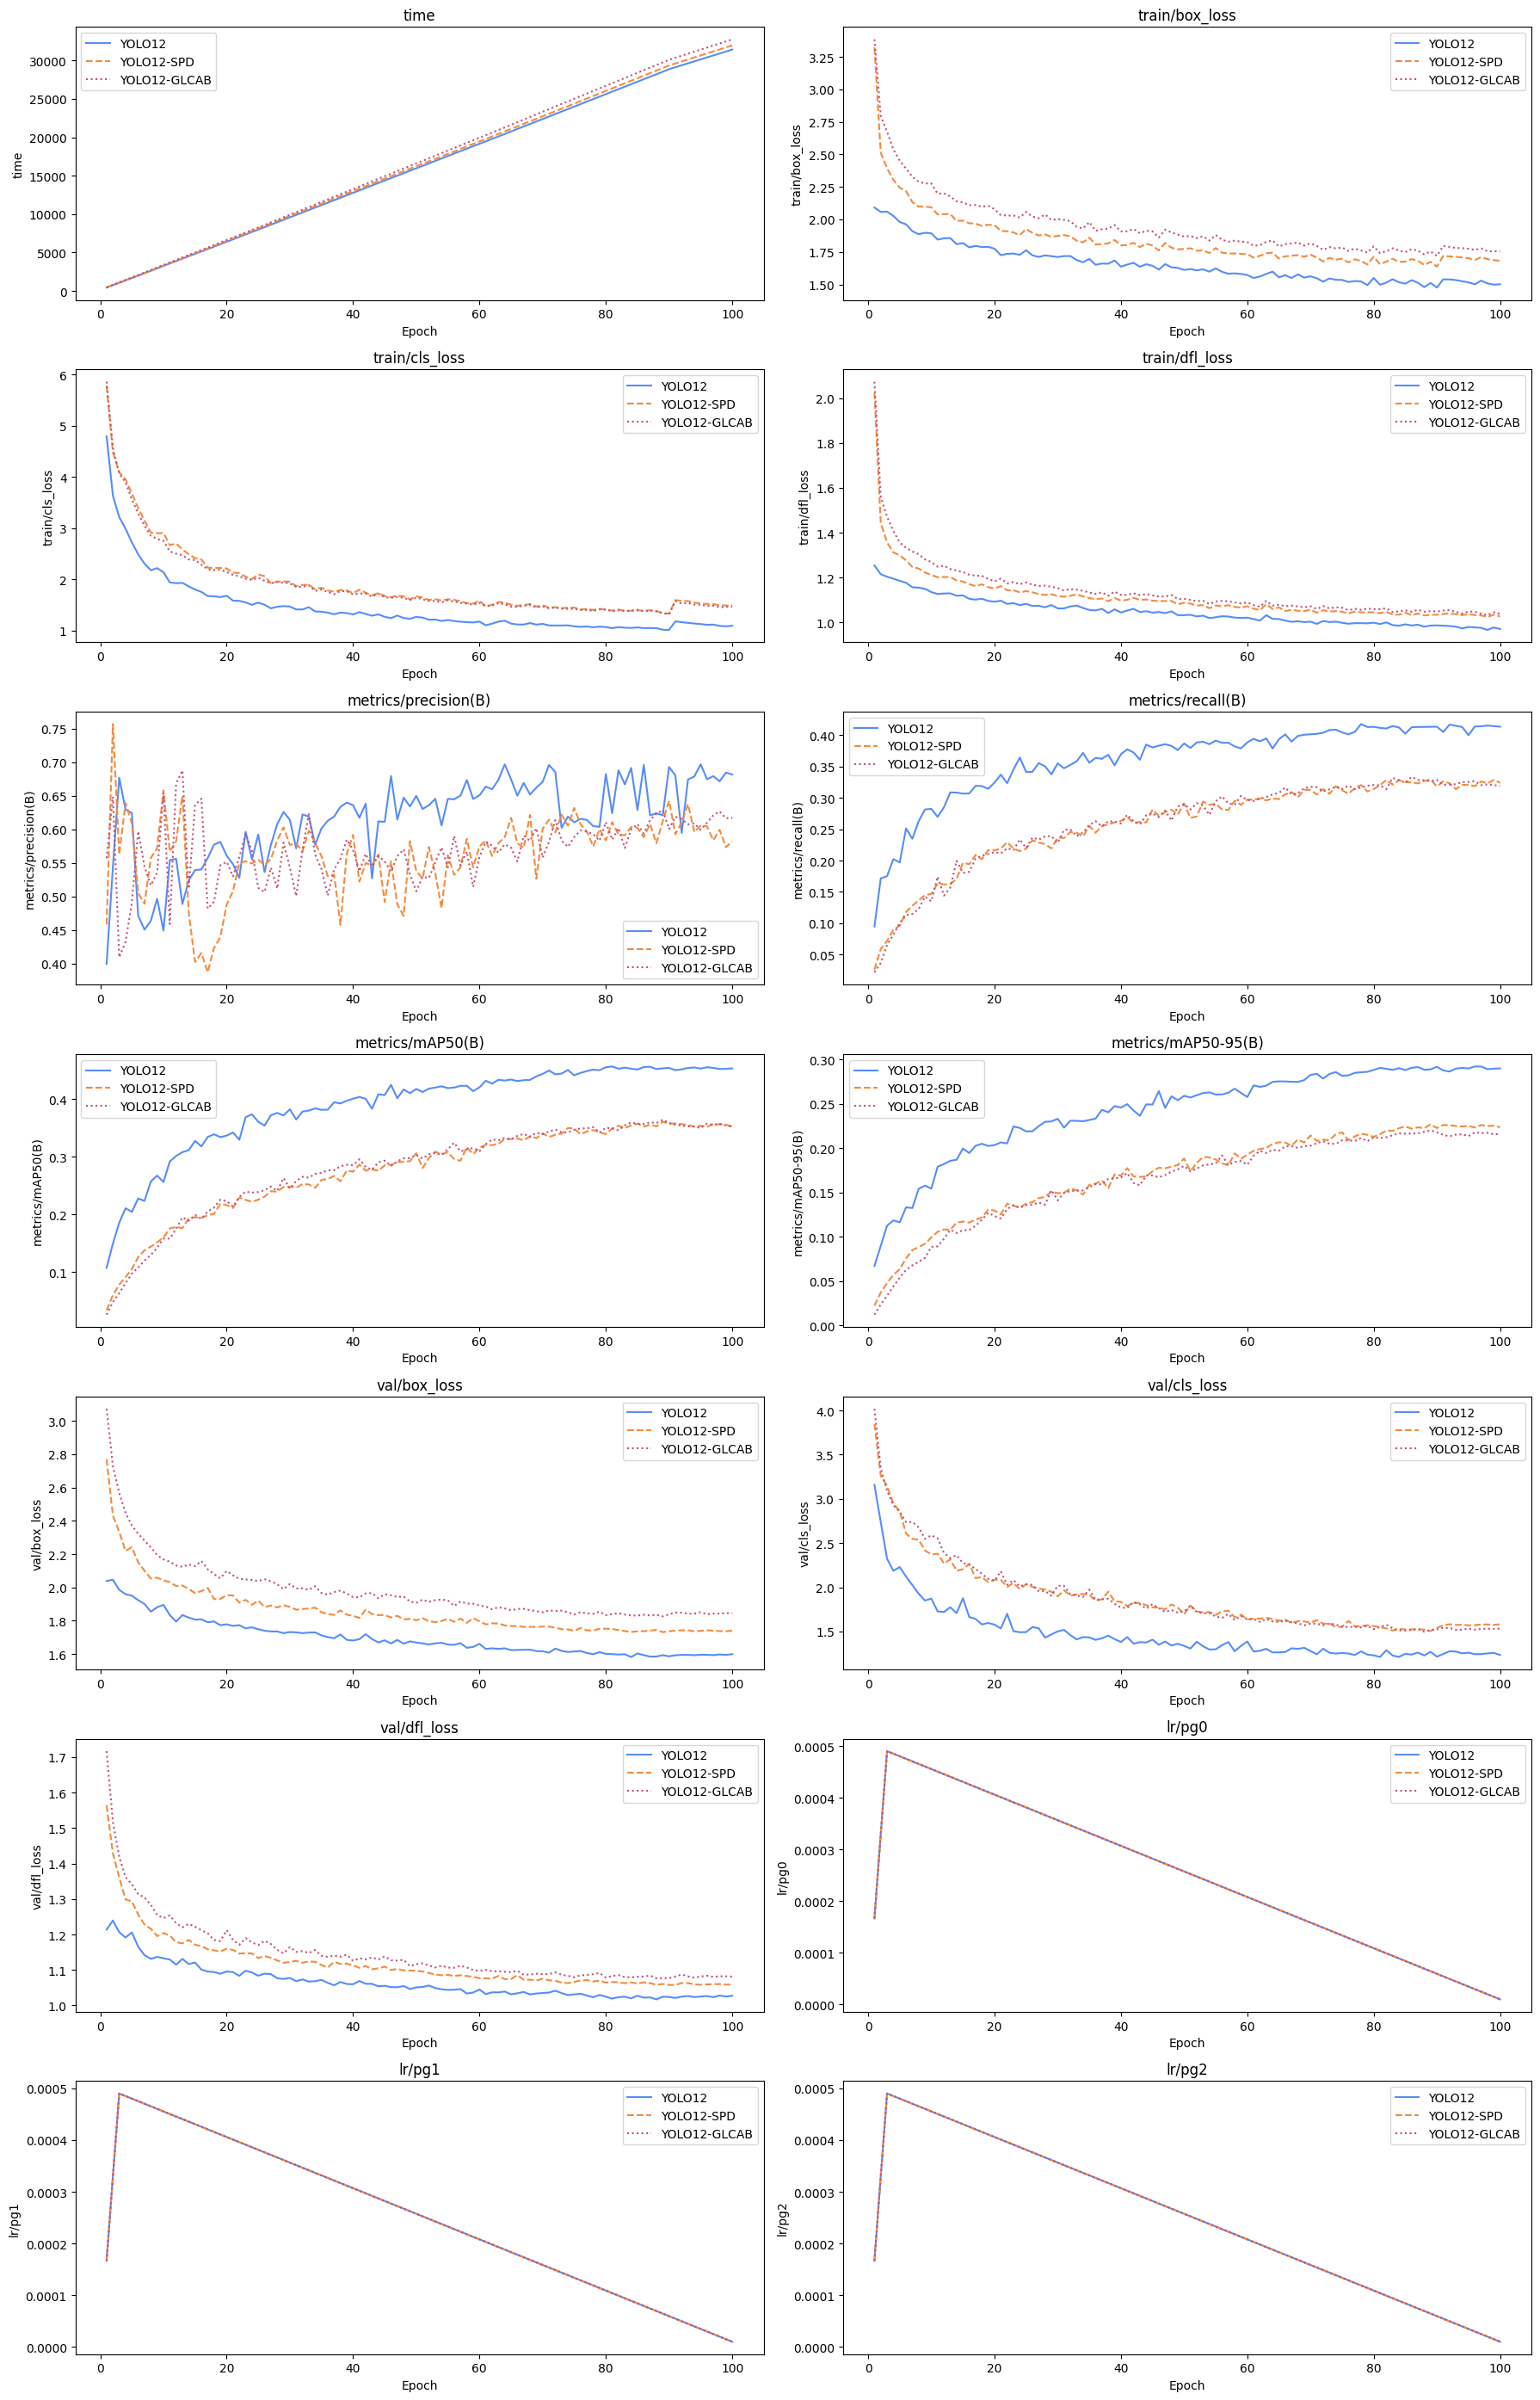

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les fichiers
df1 = pd.read_csv("rs/yolo12-DOTA-100_1280.csv")
df2 = pd.read_csv("rs/yolo12-spd-DOTA-100_1280.csv")
df3 = pd.read_csv("rs/yolo12-glcab-full-DOTA-100_1280.csv")

# Epoch (colonne 0)
epochs = df1.iloc[:, 0]

# Sélection des 14 métriques
metrics = df1.columns[1:15]

# Création des subplots (7 lignes × 2 colonnes = 14 graphes)
fig, axes = plt.subplots(7, 2, figsize=(18, 28))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].plot(epochs, df1[metric], label="YOLO12")
    axes[i].plot(epochs, df2[metric], linestyle="--", label="YOLO12-SPD")
    axes[i].plot(epochs, df3[metric], linestyle=":", label="YOLO12-GLCAB")

    axes[i].set_title(metric)
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(metric)
    axes[i].legend()

plt.tight_layout()

# Sauvegarde image
plt.savefig("comparison_metrics.png")

# Affichage
plt.show()